In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Plotting — matplotlib
    plot_gmsh_mesh, 
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    results2gmsh, opensees2gmsh,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 1.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
# General model parameters

output_path = os.getcwd()
mesh_name = '1000_06_Point06'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [4]:
# Material
Steel=Material( name='Steel',
                E=2000,
                nu=0.30,
                rho=1.25*tf/m**3*0)

# Sections
F1=Membrane(    name='F1',
                thickness=800,
                material=Steel)

# Dictionaries
section_dictionary={1586:F1,
                        }

restrain_dictionary={1585:['r', 'r']}

load_dictionary = {
                1587 :   {'value': 0.001, 'direction': '-y'},   
                

}

In [5]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (1527 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1   2152886.0885   10472221.7691   2364919.3131
       2   2152886.0860   10472221.7701   2364919.3125
       3   2152886.0885   10472221.7691   2364919.3125
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
    1585      2   'support'
    1586      2   'tunnel'
    1587      2   'load'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
    1585      2        2          3           98   'support'
    1586      2       

In [6]:
# Initialize nodes and apply Dirichlet (restraints) and Neumann (nodal loads) boundary conditions.
mesh.apply_boundary_conditions(restrain_dictionary, load_dictionary, section_dictionary, verbose=True)


  === BOUNDARY CONDITIONS ===
  Nodes created  : 1527
  system_nDof    : 3054

  --- Restrained nodes ---
     Tag              x              y   Restraints
--------------------------------------------------------------------------------
     671   2221180.8395   10455909.5956   ['r', 'r']
     672   2221309.6515   10456224.2501   ['r', 'r']
     673   2221444.2778   10456553.1079   ['r', 'r']
     674   2221752.6929   10457306.4870   ['r', 'r']
     675   2222045.3268   10458021.3166   ['r', 'r']
     676   2222337.9606   10458736.1461   ['r', 'r']
     677   2222646.3757   10459489.5252   ['r', 'r']
     679   2416314.7860   10376026.5008   ['r', 'r']
     683   2417471.9071   10378853.0513   ['r', 'r']
     684   2417780.3222   10379606.4304   ['r', 'r']
     689   2416886.6394   10377423.3922   ['r', 'r']
     690   2416578.2243   10376670.0131   ['r', 'r']
     693   2417179.2733   10378138.2218   ['r', 'r']
     702   2418184.3106   10380593.2707   ['r', 'r']
     703   2417727

In [7]:
# system_nDof = mesh.system_nDof
# node_map = mesh.node_map

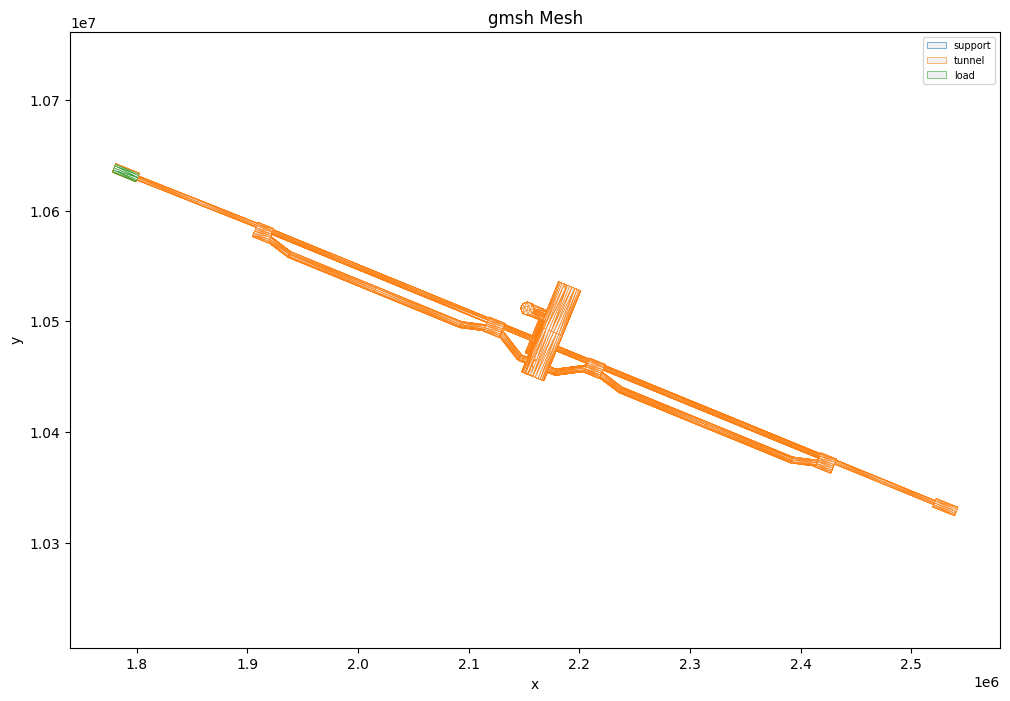

In [8]:
# %matplotlib widge
plot_gmsh_mesh(mesh,
               show_node_labels   = False,
               show_element_labels= False,
               show_node_points   = False,
            #    view_3d            = True,   elev= 45, azim= -45,
               figsize            = (12, 8))

In [9]:
# build lumped nodal force vector
F_nodal = mesh.build_load_vector(load_dictionary)

# assemble to global vector
F_load = np.zeros(mesh.system_nDof)
for tag, f_vec in F_nodal.items():
    if tag in mesh.node_map:
        F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec
F_load[np.abs(F_load) < 1e-4] = 0.0

In [10]:
# # assemble consistent load vector
# F_load = np.zeros(mesh.system_nDof)
# for node in mesh.node_map.values():
#     F_load[node.idx] += node.nodalLoad  
# for elem in elements:
#     F_load[elem.idx] += elem.F_fe_global 
# F_load[np.abs(F_load) < 1e-4] = 0.0

## Opensees

In [11]:
# import openseespy.opensees as ops
import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)



         OpenSees -- Open System For Earthquake Engineering Simulation
                 Pacific Earthquake Engineering Research Center
                        Version 3.7.2 64-Bit


      (c) Copyright 1999-2016 The Regents of the University of California
                              All Rights Reserved
  (Copyright and Disclaimer @ http://www.berkeley.edu/OpenSees/copyright.html)


  *********** (o_O) OPENSEES (>'-')> Ladruno4ever *********** 3.7.2




In [12]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [13]:
# Boundary conditions
fixed_nodes = set()
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            if tag not in fixed_nodes:
                fixed_nodes.add(tag)
                ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [14]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               Steel.E,
               Steel.nu,
               Steel.rho)

In [15]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


In [16]:
# opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [17]:
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)
for tag, force in F_nodal.items():
    if np.any(np.abs(force) > 0):
        ops.load(tag, *force.tolist())

In [18]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("BandGeneral") 
ops.numberer("RCM")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

after: 100 iterations  current Norm: nan (max: 1e-06, Norm deltaX: nan)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 0.1
OpenSees > analyze failed, returned: -3 error flag


-3

In [19]:
opensees2gmsh(
    output_file      = output_file,
    mesh             = mesh,
    ops              = ops,
    solid_group_name = 'tunnel',
    F_nodal          = F_load,
    disp_factor      = 50,
    material         = Steel,
    analysis_type    = 'planeStress',
    show_disp        = True,
    show_loads       = True,
    show_reactions   = True,
    show_stress      = True,
    show_strain      = True,
    show_vm          = True,
    show_averaged    = True,
)

AttributeError: 'numpy.ndarray' object has no attribute 'get'